# 17.综合 从论文主张到有界复现证据

## 学习目标与先修知识

核对两篇固定论文的主张、课程缩减实验、独立证据和生命系统迁移。

先修：本篇 17.1—17.4。

## 具体问题

哪一部分是原论文条件，哪一部分只是课程缩减？有限训练改善与独立失败应如何同表报告？

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先手算 Lorenz 的一个导数（derivative）和一项配对差。

In [2]:
x,y,z=-8.,7.,27.
print("原方程 x 导数",10*(y-x),"；一项误差改善",.3-.2)

原方程 x 导数 150.0 ；一项误差改善 0.09999999999999998


## 模型假设

R18 和 R19 的版本分别固定为 arXiv:1509.03580v1、arXiv:1806.07366v1。此 Notebook 只汇总本课程已执行的短窗口、二维伴随及人工双室任务；不称为原论文全配置复现。配对报告中的失败标记表示质量检查未通过，但各场景仍有可计算的数值误差（numerical error）；无输出（output）的求解失败需另定评价口径。

## 数学解释与推导

SINDy 检查 $\dot X\approx\Theta(X)\Xi$ 的项与独立轨迹（trajectory）；Neural ODE 检查伴随跳跃及与解析螺旋的梯度（gradient）对照。迁移到双室时，总量变化率由输入（input）与清除决定，交换项相消。配对误差、收支（mass balance）残差（residual）和失败率分别回答不同问题。

## 核心实现

复用本篇已展示的核验函数，保持输入、输出（output）和顺序公开。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8./3.):
    x,y,z=np.asarray(state,dtype=float)
    return np.array([sigma*(y-x),x*(rho-z)-y,x*y-beta*z],dtype=float)


def feature_row(state):
    x,y,z=np.asarray(state,dtype=float)
    return [1.,float(x),float(y),float(z),float(x*x),float(x*y),float(x*z),float(y*y),float(y*z),float(z*z)]


def spiral_rhs(state, parameters):
    """Four-parameter tanh vector field; linear damped spiral when c=d=0."""
    x,y=np.asarray(state,dtype=float);a,omega,c,d=parameters
    return np.array([-a*x-omega*y+c*np.tanh(x),omega*x-a*y+d*np.tanh(y)])


def spiral_parameter_jacobian(state, parameters):
    x,y=np.asarray(state,dtype=float)
    return np.array([[-x,-y,np.tanh(x),0.],[-y,x,0.,np.tanh(y)]])


def paired_report(baseline,method,failures):
    baseline=np.asarray(baseline,dtype=float);method=np.asarray(method,dtype=float)
    failures=np.asarray(failures,dtype=bool)
    difference=baseline-method
    return [float(difference.mean()),float(difference.std(ddof=1)/math.sqrt(len(difference))) if len(difference)>1 else 0.,float(failures.mean())]


def clearance_rhs(amounts,inputs,clearance,exchange):
    first,second=amounts;u1,u2=inputs;k1,k2=clearance
    return [u1-k1*first-exchange*(first-second),
            u2-k2*second+exchange*(first-second)]


def clearance_score(truth,prediction,total_input,total_removed,initial_total,final_total):
    truth=np.asarray(truth,dtype=float);pred=np.asarray(prediction,dtype=float)
    rmse=float(np.sqrt(np.mean((truth-pred)**2)))
    balance=float(abs(final_total-initial_total-total_input+total_removed))
    negative=int(np.sum(pred<0))
    return [rmse,balance,negative]

## 对照实验

同一图中并列方程导数、伴随参数（parameter）方向和配对差；量纲（dimension）不同，不合并成总分。

C:\Users\10149\AppData\Local\Temp\ipykernel_70844\739291382.py:2: UserWarning: The figure layout has changed to tight
  fig,axes=plt.subplots(1,3,figsize=(10,3.2));axes[0].bar(["x","y","z"],rates,color=BLUE);axes[0].set_title("Lorenz 导数");axes[1].imshow(jac,cmap="coolwarm",vmin=-1,vmax=1);axes[1].set_title("参数 Jacobian");axes[2].bar(["改进","标准误","失败率"],report,color=[GREEN,BLUE,PINK]);axes[2].set_title("配对报告");fig.tight_layout();plt.show();print("课程缩减实验，不是两篇原文的全量结果")


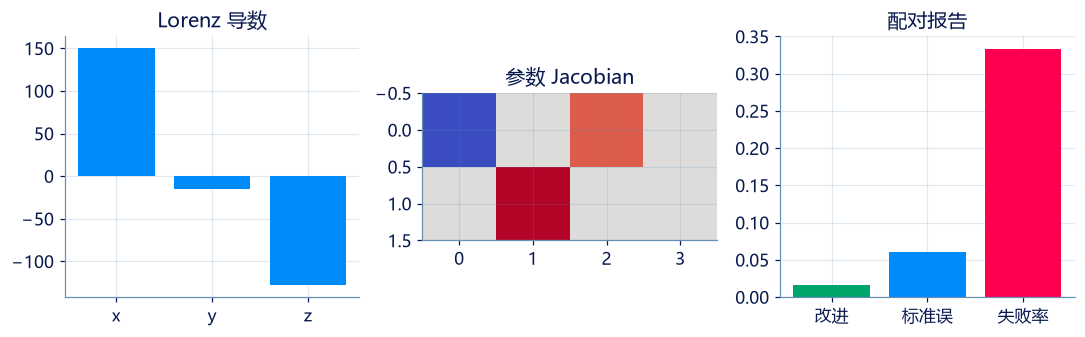

课程缩减实验，不是两篇原文的全量结果


In [4]:
rates=lorenz_rhs([-8.,7.,27.]);jac=spiral_parameter_jacobian([1.,0.],[.08,2.,0.,0.]);report=paired_report([.3,.4,.2],[.2,.5,.15],[False,True,False])
fig,axes=plt.subplots(1,3,figsize=(10,3.2));axes[0].bar(["x","y","z"],rates,color=BLUE);axes[0].set_title("Lorenz 导数");axes[1].imshow(jac,cmap="coolwarm",vmin=-1,vmax=1);axes[1].set_title("参数 Jacobian");axes[2].bar(["改进","标准误","失败率"],report,color=[GREEN,BLUE,PINK]);axes[2].set_title("配对报告");fig.tight_layout();plt.show();print("课程缩减实验，不是两篇原文的全量结果")

## 结果解释

Lorenz 核对只涉及给定方程与短窗口。连续伴随验证的是缩减模型（model）的梯度。双室迁移仅是人工生命系统模型。失败条件必须保留，任何一张相似曲线都不足以支持原论文全部结论。

### 独立核对

按已知方程、显式参数偏导（partial derivative）和手算配对差核查。

In [5]:
np.testing.assert_allclose(rates,[150.,-15.,-128.]);np.testing.assert_allclose(jac[:,1],[-0.,1.]);np.testing.assert_allclose(report[0],np.mean([.1,-.1,.05]));assert report[2]==1/3
print("独立代数参考通过。")

独立代数参考通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：主张与证据

缩减 Lorenz 窗口可检验哪项结论？

- **A.** 原文长窗全部数值
- **B.** 在当前窗口恢复所声明方程项
- **C.** 所有生理系统可解释
- **D.** 完整临床价值

[作答：主张与证据](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-claim)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：复现与改编身份

二维四参数（parameter）螺旋加连续伴随，但不含潜变量编码器，如何标记？

- **A.** 原论文 Table 2 全量复现
- **B.** 原方法核心的课程缩减实验
- **C.** 无关方法
- **D.** 真实患者复现

[作答：复现与改编身份](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-adaptation)

### 第 3 题 · 方法应用 · 15 分 · 单项选择题：协议缺口

训练和测试使用同一轨迹（trajectory）编号，最大的问题是什么？

- **A.** 积分网格过细
- **B.** 独立验证证据泄漏
- **C.** 基线过强
- **D.** 字典项过少

[作答：协议缺口](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-protocol)

### 第 4 题 · 迁移挑战 · 10 分 · 单项选择题：失败能否反驳主张

原主张仅覆盖当前观测（observation）条件，换成未声明的新传感器后失败，最准确的判断是什么？

- **A.** 原范围结论自动被推翻
- **B.** 提示迁移范围失效，不能直接反驳原范围内结论
- **C.** 证明所有方法都无效
- **D.** 应删除新条件结果

[作答：失败能否反驳主张](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-failure)

### 第 5 题 · 迁移挑战 · 10 分 · 单项选择题：复现实验的结论边界

平均效果较好但一条件失败，何种报告可信？

- **A.** 只报告成功场景
- **B.** 把失败重命名为成功
- **C.** 保留全部场景、配对差及失败率
- **D.** 凭均值宣称普遍优势

[作答：复现实验的结论边界](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-boundary)

### 第 6 题 · 方法应用 · 15 分 · Python 计算题：复现关键数值步骤

综合任务给定了独立的模型（model）输入（input）与评价条件。本题计算“复现关键数值步骤”：依次计算 sigma*(y-x)、x*(rho-z)-y、x*y-beta*z；状态（state）与时间均按 Lorenz 无量纲（dimensionless）形式给出。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    state: list[float],
    sigma: float,
    rho: float,
    beta: float,
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 按 x、y、z 顺序的无量纲当前状态。 | 1 |
| `sigma` | `float` | 归一化 Lorenz 参数。 | 1 |
| `rho` | `float` | 归一化 Lorenz 参数。 | 1 |
| `beta` | `float` | 归一化 Lorenz 参数。 | 1 |

**返回值**

直接返回 rates（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 三个状态对归一化时间的变化率。 | 1 |

**计算规则**

依次计算 sigma*(y-x)、x*(rho-z)-y、x*y-beta*z；状态与时间均按 Lorenz 无量纲形式给出。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入满足模型和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 按 x、y、z 顺序的无量纲当前状态。 | [-8.0, 7.0, 27.0] | 1 |
| sigma | 归一化 Lorenz 参数。 | 10 | 1 |
| rho | 归一化 Lorenz 参数。 | 28 | 1 |
| beta | 归一化 Lorenz 参数。 | ≈ 2.666667 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [-8.0, 7.0, 27.0]
sigma = 10.0
rho = 28.0
beta = 2.6666666666666665

result = solve(state, sigma, rho, beta)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | 三个状态对归一化时间的变化率。 | [150.0, -15.0, -128.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [150.0, -15.0, -128.0]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；依次计算 sigma*(y-x)、x*(rho-z)-y、x*y-beta*z；状态与时间均按 Lorenz 无量纲形式给出。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：复现关键数值步骤](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-lorenz)

### 第 7 题 · 综合验证 · 15 分 · Python 计算题：消融的配对统计

综合任务给定了独立的模型（model）输入（input）与评价条件。本题计算“消融的配对统计”：配对差 d=baseline-method；标准误（standard error）为样本标准差（standard deviation）/sqrt(n)，n=1 时规定为0；失败表示候选仍有数值预测，但未通过质量检查；对应误差继续参与配对统计，失败率使用全部场景。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    baseline: list[float],
    method: list[float],
    failures: list[bool],
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `baseline` | `list[float]` | 全部场景的基线误差。 | U |
| `method` | `list[float]` | 同序候选数值预测的误差；质量检查失败时仍有定义。 | U |
| `failures` | `list[bool]` | 候选有数值预测，但未通过预设质量检查（如收支（mass balance）或非负性（nonnegativity））的标志。 | 1 |

**返回值**

直接返回 report（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `report` | `list[float]` | 基线减候选的均值、样本标准误和失败率。 | 混合 |

**计算规则**

每组都有定义明确的基线和候选误差；failures=True 仅表示候选数值预测未通过预设质量检查。全部场景均进入 d=baseline-method 的均值和标准误计算；标准误为样本标准差/sqrt(n)，n=1 时取 0。失败率为 True 数量/全部场景数。无有效数值输出（output）的求解失败不属于本接口；此时应另报双方成功场景的配对统计和全体失败率。

**约束与边界**

- 三个列表等长且至少一组；全部误差有限，列表规模不超过 100；按题给顺序返回。
- 输入满足模型和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| baseline | 全部场景的基线误差。 | [0.3, 0.4] | U |
| method | 同序候选数值预测的误差；质量检查失败时仍有定义。 | [0.2, 0.5] | U |
| failures | 候选有数值预测，但未通过预设质量检查（如收支（mass balance）或非负性（nonnegativity））的标志。 | [False, True] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
baseline = [0.3, 0.4]
method = [0.2, 0.5]
failures = [False, True]

result = solve(baseline, method, failures)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| report | 基线减候选的均值、样本标准误和失败率。 | [0.0, 0.09999999999999998, 0.5] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.09999999999999998, 0.5]
```

**样例解释**

第二组虽标记质量检查失败，候选误差 0.5 U 仍有定义。两组配对差为 0.1 与 -0.1 U，均值为 0、标准误为 0.1 U；失败率为 1/2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：消融的配对统计](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-paired)

### 第 8 题 · 综合验证 · 15 分 · Python 计算题：跨方法约束指标

综合任务给定了独立的模型（model）输入（input）与评价条件。本题计算“跨方法约束指标”：残差（residual）为 abs(final_total-initial_total-total_input+total_removed)；负值严格按 prediction<0 计数。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    prediction: list[float],
    total_input: float,
    total_removed: float,
    initial_total: float,
    final_total: float,
) -> list:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 共同测试的真实状态（state）。 | U |
| `prediction` | `list[float]` | 同序预测状态。 | U |
| `total_input` | `float` | 评估窗输入积分。 | U |
| `total_removed` | `float` | 评估窗清除积分。 | U |
| `initial_total` | `float` | 起点总量。 | U |
| `final_total` | `float` | 终点总量。 | U |

**返回值**

直接返回 score（list）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `score` | `list` | RMSE、总量收支（mass balance）残差、负预测值个数。 | 混合 |

**计算规则**

残差为 abs(final_total-initial_total-total_input+total_removed)；负值严格按 prediction<0 计数。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入满足模型和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 共同测试的真实状态（state）。 | [1.0, 2.0] | U |
| prediction | 同序预测状态。 | [1.0, -1.0] | U |
| total_input | 评估窗输入积分。 | 0.5 | U |
| total_removed | 评估窗清除积分。 | 0.2 | U |
| initial_total | 起点总量。 | 3 | U |
| final_total | 终点总量。 | 3.3 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [1.0, 2.0]
prediction = [1.0, -1.0]
total_input = 0.5
total_removed = 0.2
initial_total = 3.0
final_total = 3.3

result = solve(truth, prediction, total_input, total_removed, initial_total, final_total)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| score | RMSE、总量收支（mass balance）残差、负预测值个数。 | [2.1213203435596424, 1.6653345369377348e-16, 1] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.1213203435596424,
                   1.6653345369377348e-16,
                   1]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；残差为 abs(final_total-initial_total-total_input+total_removed)；负值严格按 prediction<0 计数。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：跨方法约束指标](http://127.0.0.1:8000/parts/17-%E7%A0%94%E7%A9%B6%E5%A4%8D%E7%8E%B0%E4%B8%8E%E7%BB%BC%E5%90%88%E5%AE%9E%E8%B7%B5/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p17-capstone-score)